In [1]:
# USER INPUT HERE
user_lambda = 0.1 # choose your value of lambda, should be in (0,+inf)

Import packages and data
---------------

In [2]:
# IMPORT PACKAGES
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from yield_curve_functions import DNS_OLS, DNS_formula # import our custom functions

In [5]:
# IMPORT DATA
y_df = pd.read_excel('US_daily.xlsx')
y = y_df.to_numpy()
matu = np.array([[1/12,3/12,6/12,1,2,3,5,7,10,20,30]])

dates = y[:,0]

current=1 #this variable keeps track of the dates in the original dataset that have already been added. It is a row index in the original table.
currentDate = np.datetime64(dates[0]) # this variable keeps track of all dates that need to be added.

# The following two tables will be concatenated horizontally to create the full, new dataset
CompleteTable = np.array([y[0,1:]]) #Table with added yields (has copied lines where extra dates have been added)
CompleteDates = np.array([[currentDate]], dtype='datetime64') #Will be the full dates column

AddDay = np.timedelta64(1,'D')

cdnp = np.array([[currentDate]],dtype='datetime64') #single entry array. Used to have a compatible format (np.array) for adding the dates to CompleteDates.

while current<y_df.shape[0]:
    currentDate = currentDate + AddDay
    cdnp[0][0] = currentDate
    CompleteDates = np.hstack((CompleteDates,cdnp))
    dateInTable = np.datetime64(dates[current])
    
    if dateInTable != currentDate:
        CompleteTable = np.vstack((CompleteTable,CompleteTable[-1])) #copies last available line into the table
        
    if dateInTable == currentDate:
        CompleteTable = np.vstack((CompleteTable,y[current,1:])) #adds yield curve corresponding to currentDate
        current = current + 1

#Updating to full table
y = np.hstack((CompleteDates.transpose(), CompleteTable))
dates = np.array([y[:,0]])
y = np.delete(y,0,1) #seperating dates and yields
y = np.array(y,dtype = float)

Fit 4 randomly selected yield curves through Nelson-Siegel family
----------

In [6]:
# SELECT RANDOMLY 4 DAYS TO DISPLAY, CALCULATE THE NELSON-SIEGEL FIT
t_display = np.sort( np.random.choice( y.shape[0], size=4, replace=False ) )
y_now = y[t_display,:]

# OLS fitting of the coefficients
user_ts = DNS_OLS(y_now,matu,user_lambda) 

our_lambda = 0.496 
our_ts = DNS_OLS(y_now,matu,our_lambda) 

DL_lambda = 0.0609
DL_ts = DNS_OLS(y_now,matu,DL_lambda)

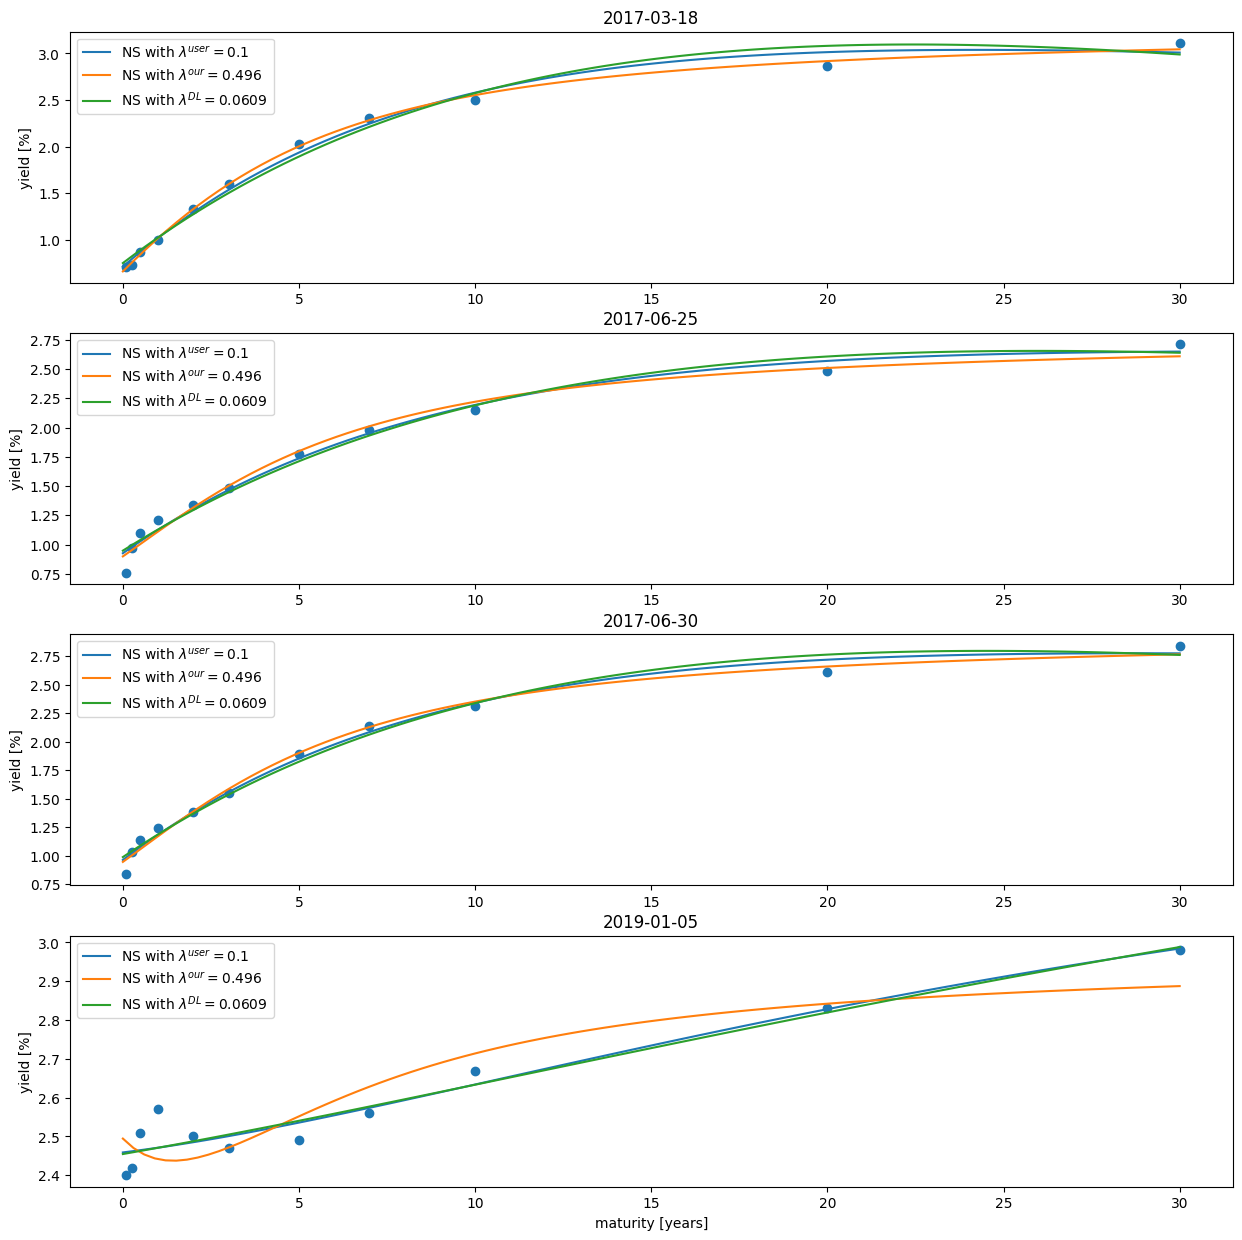

In [7]:
# DRAW 4 RANDOMLY CHOOSEN YIELD CURVES, INTERPOLATE WITH VARIOS VALUES OF LAMBDA
# lambda^user .... the lambda defined by the user for exploration
# lambda^ours = 0.496 the lambda used in our analysis, was determined to minimise least squares
# lambda^DL = 0.0609  the value of lambda recommended by Diebold and Li (2006)

# visualise the static NS fit for fixed time
tau_grid = np.linspace(start=0.001, stop=30, num=100)

f, axarr = plt.subplots(4, 1, figsize=(15,15))
for ii in range(4):    
    #f, (ax1, ax2) = plt.subplot(4, 1, ii+1,figsize=(15,15))    
    axarr[ii].plot( tau_grid, DNS_formula( tau_grid, user_ts[ii,:], user_lambda ) )
    axarr[ii].plot( tau_grid, DNS_formula( tau_grid, our_ts[ii,:], our_lambda ) )
    axarr[ii].plot( tau_grid, DNS_formula( tau_grid, DL_ts[ii,:], DL_lambda ) )    
    axarr[ii].scatter(matu,y_now[ii])
    axarr[ii].set_title( dates[0,t_display[ii]].date() )
    axarr[ii].set_ylabel("yield [%]")
    axarr[ii].legend([r'NS with $\lambda^{user}=$'+str(user_lambda),r'NS with $\lambda^{our} = 0.496$',r'NS with $\lambda^{DL} = 0.0609$'])
    if ii == 3:
        axarr[ii].set_xlabel("maturity [years]")
